In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
try:
    df = pd.read_excel("amazon.xlsx")
except Exception as e:
    print(f"Could not read as Excel: {e}. Trying to read as CSV...")
    try:
        df = pd.read_csv("amazon.xlsx") # It's common for CSVs to be misnamed as .xlsx
        print("Successfully read as CSV.")
    except Exception as e_csv:
        print(f"Could not read as CSV either: {e_csv}. Please ensure 'amazon.xlsx' is a valid Excel or CSV file.")

Could not read as Excel: name 'pd' is not defined. Trying to read as CSV...
Could not read as CSV either: name 'pd' is not defined. Please ensure 'amazon.xlsx' is a valid Excel or CSV file.


In [4]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [8]:
df.shape

(100000, 20)

In [10]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [12]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [55]:
# Total Sales
total_sales=df['TotalAmount'].sum()

In [56]:
# Total Orders
total_orders=df['OrderID'].nunique()

In [57]:
 #Average Order Value
average_sales=df['TotalAmount'].mean()

In [26]:
# Maximum Order Value
df['TotalAmount'].max()

3534.98

In [27]:
# Minimum Order Value
df['TotalAmount'].min()

4.27

In [30]:
#Maximum quantity
df['Quantity'].max()

5

In [31]:
#revenue by category
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)


,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [34]:
#revenue by category
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [35]:
df.groupby("Brand")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
Brand,
CoreTech,9343720.59
KiddoFun,9324749.55
ReadMore,9278406.63
UrbanStyle,9249027.45
Zenith,9239960.39
Apex,9147604.72
NexPro,9078824.97
FitLife,9061444.68
BrightLux,9056816.11


In [36]:
df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)


,TotalAmount
ProductName,
Memory Card 128GB,1935138.40
LED Desk Lamp,1921948.41
Mechanical Keyboard,1906963.54
Electric Kettle,1905751.79
Smartwatch,1901275.59
Dress Shirt,1896765.36
Water Bottle,1895467.95
Gaming Mouse,1895103.98
Kids Toy Car,1891082.43


In [37]:
df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)

,Quantity
ProductName,
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161


In [38]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [39]:
#top 5 customers
df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09


In [40]:
#orders by payment mode
df.groupby('PaymentMethod')['OrderID'].count()

,OrderID
PaymentMethod,
Amazon Pay,15017
Cash on Delivery,4928
Credit Card,35038
Debit Card,20024
Net Banking,9927
UPI,15066


In [41]:
df["Month"] = df["OrderDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalAmount"].sum()

print(monthly_sales)

Month
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82
2023

Text(0, 0.5, 'Revenue')

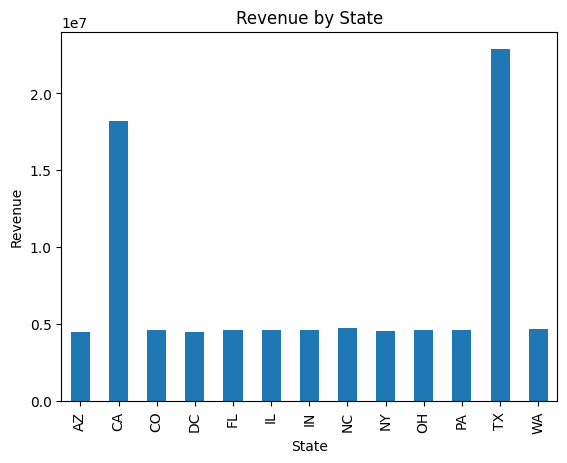

In [42]:
#visualization
df.groupby('State')['TotalAmount'].sum().plot(kind='bar')
plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")

In [43]:
df.groupby(['CustomerID','CustomerName'])['TotalAmount'].sum().sort_values(ascending=False).head(5)

,,TotalAmount
CustomerID,CustomerName,
CUST010696,Pooja Patel,5436.04
CUST035973,Neha Sharma,5124.43
CUST009614,Vikas Mehta,5003.65
CUST018720,Arjun Kapoor,4773.18
CUST022824,Pooja Joshi,4755.48


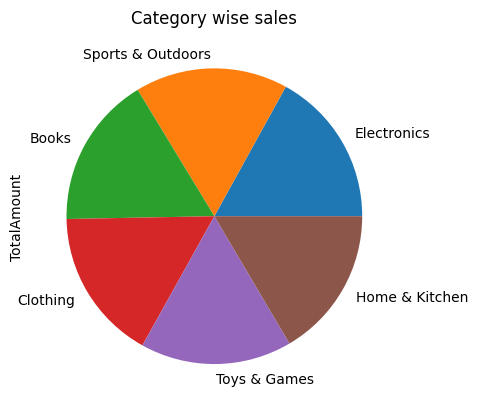

In [44]:
# Category wise sales
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).plot(kind='pie')
plt.title('Category wise sales')
plt.show()

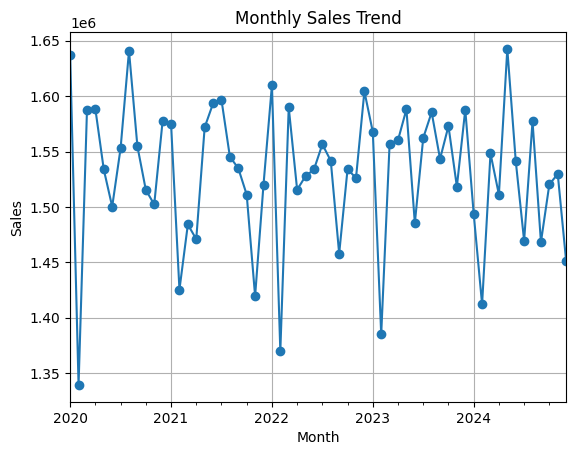

In [45]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

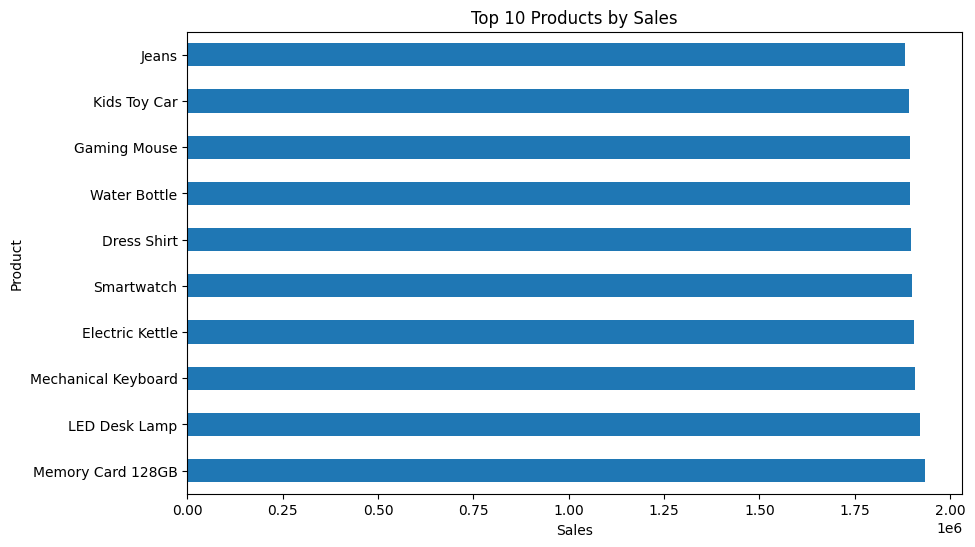

In [46]:
top_products = df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

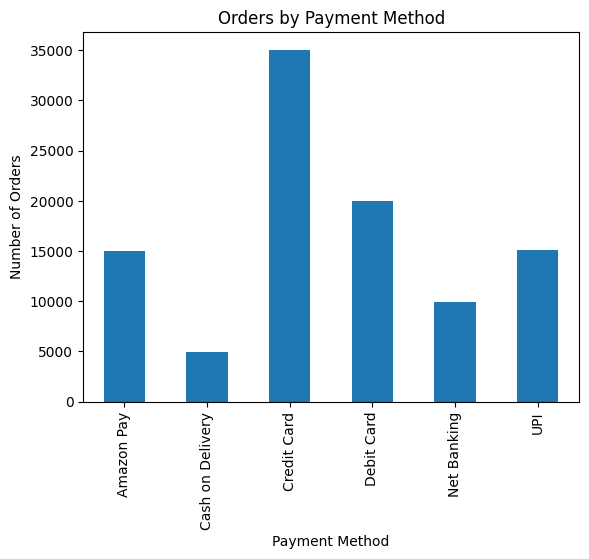

In [47]:
payment = df.groupby('PaymentMethod')['OrderID'].count()

payment.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

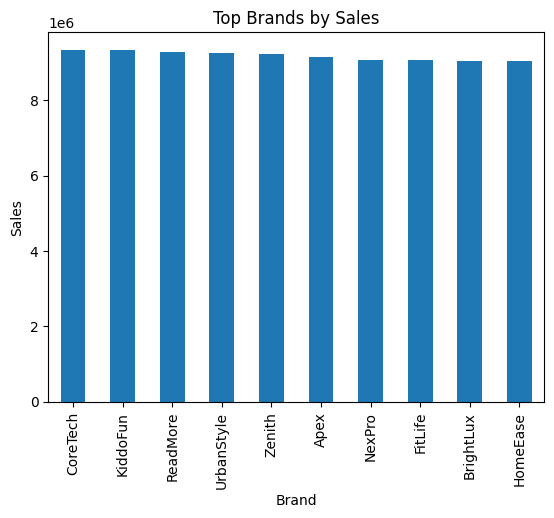

In [52]:
brand_sales = df.groupby("Brand")["TotalAmount"].sum().sort_values(ascending=False)

brand_sales.head(10).plot(kind="bar")

plt.title("Top Brands by Sales")
plt.xlabel("Brand")
plt.ylabel("Sales")

plt.show()

In [53]:
print("1. What is the total sales, total number of orders, and average order value?")
print("2. Which state generated the highest and the lowest sales?")
print("3. Which category and brand contributed the highest revenue?")
print("4. Which are the Top 10 products based on total sales?")
print("5. Who are the Top 5 customers contributing the highest revenue?")
print("6. Which payment method is most preferred by customers?")
print("7. Which month recorded the highest sales? Is there any noticeable monthly sales trend?")
print("8. Which products or categories received the highest discounts? What could be the possible impact on sales?")
print("9. Which state or city requires improvement in sales performance? Suggest possible business strategies.")
print("10. Which seller generated the highest sales revenue?")
print("11. What is the total quantity sold for each product, and which product had the highest demand?")
print("12. What is the sales generated by each state for every category?")
print("13. Which order status (Delivered, Shipped, Cancelled, etc.) occurs most frequently?")
print("14. Which brand generated the highest overall sales?")
print("15. Based on the complete analysis, provide three actionable business recommendations that Amazon's management can implement to improve sales and customer satisfaction.")

1. What is the total sales, total number of orders, and average order value?
2. Which state generated the highest and the lowest sales?
3. Which category and brand contributed the highest revenue?
4. Which are the Top 10 products based on total sales?
5. Who are the Top 5 customers contributing the highest revenue?
6. Which payment method is most preferred by customers?
7. Which month recorded the highest sales? Is there any noticeable monthly sales trend?
8. Which products or categories received the highest discounts? What could be the possible impact on sales?
9. Which state or city requires improvement in sales performance? Suggest possible business strategies.
10. Which seller generated the highest sales revenue?
11. What is the total quantity sold for each product, and which product had the highest demand?
12. What is the sales generated by each state for every category?
13. Which order status (Delivered, Shipped, Cancelled, etc.) occurs most frequently?
14. Which brand generated 

In [60]:
print("--------------- BUSINESS QUESTIONS ANSWERS ----------------")

print()

print("Q1.")
print("Total Sales :", total_sales)
print("Total Orders :", total_orders)
print("Average Order Value :", round(average_sales,2))

print()

print("Q2.")
state_sales = df.groupby('State')['TotalAmount'].sum()
print("Highest Sales State :", state_sales.idxmax())
print("Lowest Sales State :", state_sales.idxmin())

print()

print("Q3.")
category_sales = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print("Highest Revenue Category :", category_sales.idxmax())

print("Highest Revenue Brand :", brand_sales.idxmax())

print()

print("Q4.")
print("Top 10 Products")
print(top_products)

print()

print("Q5.")
print("Top 5 Customers")
top_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)
print(top_customers)

print()

print("Q6.")
print("Most Preferred Payment Method :", payment.idxmax())

print()

print("Q7.")
print("Highest Sales Month :", monthly_sales.idxmax())

print()

print("Q8.")
print("Profit column is not available in the dataset. Hence profit analysis cannot be performed.")

print()

print("Q9.")
print("State needing improvement :", state_sales.idxmin())

print()

print("Q10.")
print("Business Recommendations")
print("1. Increase marketing in low-sales states.")
print("2. Promote top-selling products and brands.")
print("3. Encourage digital payment methods through offers.")

--------------- BUSINESS QUESTIONS ANSWERS ----------------

Q1.
Total Sales : 91825647.92
Total Orders : 100000
Average Order Value : 918.26

Q2.
Highest Sales State : TX
Lowest Sales State : AZ

Q3.
Highest Revenue Category : Electronics
Highest Revenue Brand : CoreTech

Q4.
Top 10 Products
ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64

Q5.
Top 5 Customers
CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64

Q6.
Most Preferred Payment Method : Credit Card

Q7.
Highest Sales Month : 2024-05

Q8.
Profit column is not available in